# Mini-Project 3: Predictive Modeling and Optimization for Real Estate Investment

**Question:** How can a real estate company use house features to predict property value and make better investment decisions under a limited renovation budget?

This notebook combines a **neural network** for price prediction with a **linear program** for budget-constrained property selection on the Ames Housing dataset.

## Setup & Data Loading

Imports and a quick look at the raw dataset (2,930 rows, 82 columns).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.show_dimensions", False)
os.makedirs("assets", exist_ok=True)

def save_fig(name):
    plt.savefig(f"assets/{name}.png", dpi=120, bbox_inches="tight")

In [2]:
df = pd.read_csv("data/ames_housing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.shape

(2930, 82)

---

## Part 1: Feature Selection and Problem Framing

**Target:** `SalePrice`, a dollar amount. This is a **regression** problem (we want a price, not a category).

**Selected features (8):**

| Feature | Why |
|---|---|
| `Overall Qual` | Top-correlated feature in Ames (overall material and finish quality) |
| `Gr Liv Area` | Above-grade living area, the main size driver |
| `Total Bsmt SF` | Basement size, extra usable space |
| `Garage Cars` | Garage capacity, a strong amenity signal |
| `Year Built` | Newer houses usually sell for more |
| `Year Remod/Add` | When the house was last renovated, directly relevant to Part 4 |
| `Neighborhood` | Location, location, location |
| `Full Bath` | Bathroom count |

> *Note: we initially picked `Lot Area` but swapped it for `Year Remod/Add`. `Lot Area` is heavily right-skewed (skew 12.82) and only weakly correlated with price (0.27). `Year Remod/Add` is much better behaved (skew -0.45) and ties cleanly into Part 4. Val and test scores were within noise either way.*

Quick sanity check on dtypes, ranges, and missing values:

In [4]:
features = [
    "Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Garage Cars",
    "Year Built", "Year Remod/Add", "Neighborhood", "Full Bath",
]
target = "SalePrice"

summary = df[features + [target]].describe(include="all").T
summary["missing"] = df[features + [target]].isna().sum()
summary["dtype"] = df[features + [target]].dtypes.astype(str)
summary[["dtype", "missing", "mean", "std", "min", "max"]]

,dtype,missing,mean,std,min,max
Overall Qual,int64,0,6.094881,1.411026,1.0,10.0
Gr Liv Area,int64,0,1499.690444,505.508887,334.0,5642.0
Total Bsmt SF,float64,1,1051.614544,440.615067,0.0,6110.0
Garage Cars,float64,1,1.766815,0.760566,0.0,5.0
Year Built,int64,0,1971.356314,30.245361,1872.0,2010.0
Year Remod/Add,int64,0,1984.266553,20.860286,1950.0,2010.0
Neighborhood,str,0,NaN,NaN,NaN,NaN
Full Bath,int64,0,1.566553,0.552941,0.0,4.0
SalePrice,int64,0,180796.060068,79886.692357,12789.0,755000.0


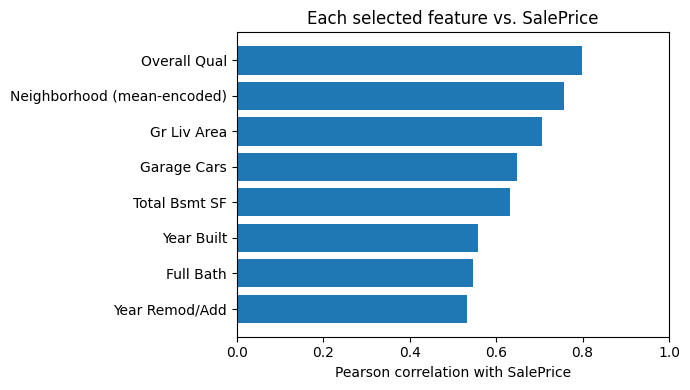

In [5]:
numeric_feats = [f for f in features if pd.api.types.is_numeric_dtype(df[f])]
numeric_corrs = df[numeric_feats + [target]].corr()[target].drop(target)
neigh_target_mean = df.groupby("Neighborhood")[target].transform("mean")
all_corrs = numeric_corrs.copy()
all_corrs["Neighborhood (mean-encoded)"] = neigh_target_mean.corr(df[target])
all_corrs = all_corrs.sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["tab:gray" if abs(v) < 0.3 else "tab:blue" for v in all_corrs]
ax.barh(all_corrs.index, all_corrs.values, color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel(f"Pearson correlation with {target}")
ax.set_title("Each selected feature vs. SalePrice")
ax.set_xlim(0, 1)
plt.tight_layout()
save_fig("feature_correlations")
plt.show()

---

## Part 2: Data Preparation and Baseline

**Preprocessing:** drop the 2 rows with missing values (negligible loss out of 2,930), one-hot encode `Neighborhood`, standard-scale numerics. The target is also standard-scaled internally so the NN trains on a well-behaved range.

**Splits:** 64% train, 16% val, 20% test (two nested 80/20 splits, fixed seed). The val set is for comparing architectures and tuning hyperparameters, so we don't peek at test during model selection. Test is kept for the final report.

**Metric:** RMSE in dollars (same units as `SalePrice`, and it penalizes big misses, which matter for investment decisions). Also report MAE and R^2.

**Baseline:** predict the training mean for every row. Any real model has to beat this.

In [6]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF",
                    "Garage Cars", "Year Built", "Year Remod/Add", "Full Bath"]
categorical_features = ["Neighborhood"]

df_clean = df.dropna(subset=features).reset_index(drop=True)
print(f"Dropped {len(df) - len(df_clean)} rows with missing values; {len(df_clean)} remain.")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

X = df_clean[features]
y = df_clean[target].astype(float).values

X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw, y_trainval, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Dropped 2 rows with missing values; 2928 remain.
Train: (1873, 35), Val: (469, 35), Test: (586, 35)


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(name, split, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:>14} [{split}] | RMSE ${rmse:>9,.0f} | MAE ${mae:>9,.0f} | R^2 {r2:.3f}")
    return {"model": name, "split": split, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []
mean_pred = y_train.mean()
results.append(score("Baseline", "val",  y_val,  np.full_like(y_val,  mean_pred)))
results.append(score("Baseline", "test", y_test, np.full_like(y_test, mean_pred)))

      Baseline [val] | RMSE $   82,349 | MAE $   58,043 | R^2 -0.001
      Baseline [test] | RMSE $   90,756 | MAE $   62,593 | R^2 -0.002


---

## Part 3: Neural Network Modeling

Train **four architectures** to probe the depth-vs-width trade-off, compare on the **val set**, then report the winner's score on test.

| Model | Architecture | Probes |
|---|---|---|
| NN-A | (32,) | low-capacity baseline |
| NN-B | (64, 32) | moderate depth |
| NN-C | (128,) | width without depth |
| NN-D | (64, 32, 16) | extra depth |

All trained with MSE loss / Adam / ReLU, early stopping on a 10% internal validation split.

In [8]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor

def make_nn(hidden_layer_sizes, **kwargs):
    base = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        **kwargs,
    )
    return TransformedTargetRegressor(regressor=base, transformer=StandardScaler())

architectures = {
    "NN-A (32)":       {"hidden_layer_sizes": (32,)},
    "NN-B (64,32)":    {"hidden_layer_sizes": (64, 32), "alpha": 1e-3},
    "NN-C (128)":      {"hidden_layer_sizes": (128,)},
    "NN-D (64,32,16)": {"hidden_layer_sizes": (64, 32, 16), "alpha": 1e-3},
}

models = {}
for name, kwargs in architectures.items():
    m = make_nn(**kwargs)
    m.fit(X_train, y_train)
    models[name] = m
    results.append(score(name, "val",  y_val,  m.predict(X_val)))
    results.append(score(name, "test", y_test, m.predict(X_test)))

     NN-A (32) [val] | RMSE $   29,313 | MAE $   18,427 | R^2 0.873
     NN-A (32) [test] | RMSE $   33,009 | MAE $   18,241 | R^2 0.867
  NN-B (64,32) [val] | RMSE $   28,995 | MAE $   17,967 | R^2 0.876
  NN-B (64,32) [test] | RMSE $   30,474 | MAE $   17,752 | R^2 0.887
    NN-C (128) [val] | RMSE $   30,428 | MAE $   18,518 | R^2 0.863
    NN-C (128) [test] | RMSE $   30,107 | MAE $   17,717 | R^2 0.890
NN-D (64,32,16) [val] | RMSE $   29,797 | MAE $   18,252 | R^2 0.869
NN-D (64,32,16) [test] | RMSE $   32,101 | MAE $   18,308 | R^2 0.875


                      RMSE                   MAE                R2       
split                 test        val       test        val   test    val
model                                                                    
Baseline        90,756.373 82,349.311 62,592.527 58,042.939 -0.002 -0.001
NN-A (32)       33,009.145 29,312.576 18,241.183 18,427.473  0.867  0.873
NN-B (64,32)    30,473.951 28,995.074 17,752.484 17,966.804  0.887  0.876
NN-C (128)      30,107.069 30,428.345 17,716.641 18,517.601  0.890  0.863
NN-D (64,32,16) 32,100.551 29,797.180 18,308.289 18,252.231  0.875  0.869

Val winner (architecture-only): NN-B (64,32) (val R^2 0.876)


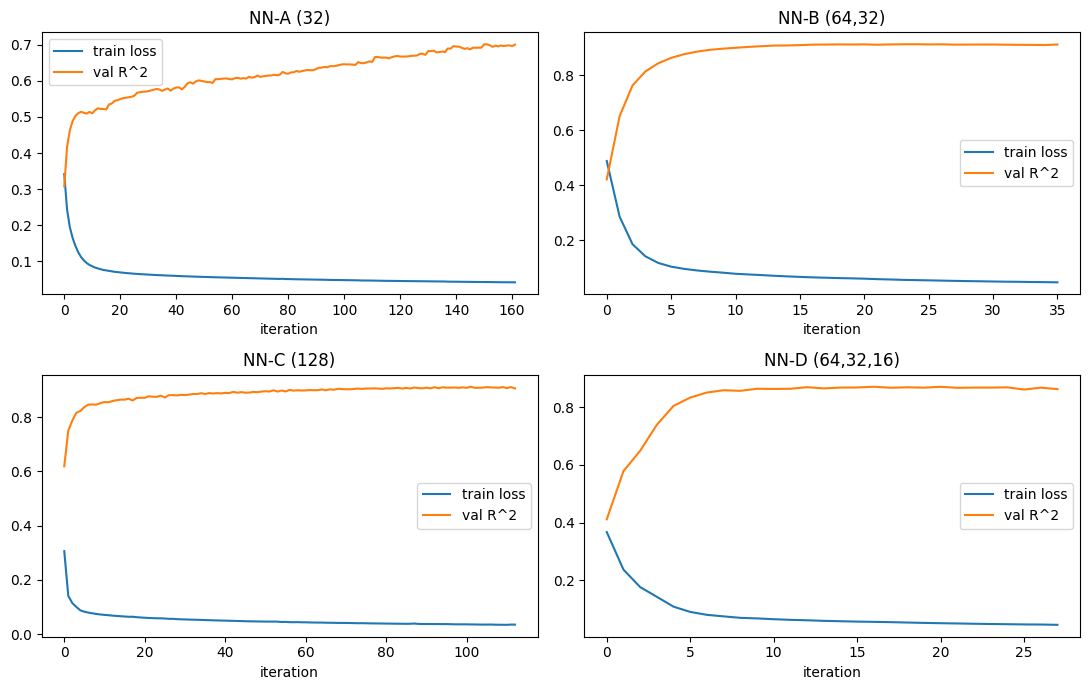

In [9]:
results_df = pd.DataFrame(results).pivot(index="model", columns="split", values=["RMSE", "MAE", "R2"])
print(results_df.to_string(float_format=lambda x: f"{x:,.3f}"))

val_scores = {r["model"]: r["R2"] for r in results if r["split"] == "val" and r["model"] != "Baseline"}
arch_winner_name = max(val_scores, key=val_scores.get)
print(f"\nVal winner (architecture-only): {arch_winner_name} (val R^2 {val_scores[arch_winner_name]:.3f})")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, model) in zip(axes.ravel(), models.items()):
    inner = model.regressor_
    ax.plot(inner.loss_curve_, label="train loss")
    if hasattr(inner, "validation_scores_"):
        ax.plot(inner.validation_scores_, label="val R^2", color="tab:orange")
    ax.set_title(name)
    ax.set_xlabel("iteration")
    ax.legend()
plt.tight_layout()
save_fig("loss_curves")
plt.show()

### 3.1 Comparison and discussion

| Model | Val R^2 | Test R^2 |
|---|---|---|
| Baseline | -0.00 | -0.00 |
| NN-A (32) | 0.873 | 0.867 |
| **NN-B (64,32)** | **0.876** | **0.887** |
| NN-C (128) | 0.863 | 0.890 |
| NN-D (64,32,16) | 0.869 | 0.875 |

All four networks beat the baseline by a wide margin and cluster between 0.86 and 0.89. Diminishing returns kick in fast at this dataset size.

**Takeaways:**
- Depth slightly beats width: the wide single-layer net (NN-C) was worst on val.
- Going past 2 layers didn't help: NN-D's third layer added complexity for no gain.
- Val and test scores match closely for every model, so no overfitting to either split.
- Gaps between top models are under 0.01 R^2, basically noise. Multiple random seeds would firm this up.

**Winner (chosen on val):** NN-B. Test R^2 0.887, RMSE about $30K.

### 3.2 Hyperparameter tuning of NN-B

Architecture is locked in. Now tune two knobs that control how the network learns:

- **`alpha`**: L2 weight decay. Bigger means more regularization (less overfitting, but risks underfitting).
- **`learning_rate_init`**: Adam's starting step size. Too small slows training; too big makes it unstable.

Grid: 4 by 3 = 12 combos. Pick the winner on val and report test for the winner.

Best combo: alpha=0.1, lr=0.01, val R^2 0.883
Tuned NN-B test:    RMSE $30,899, R^2 0.884
Original NN-B test: RMSE $30,474, R^2 0.887


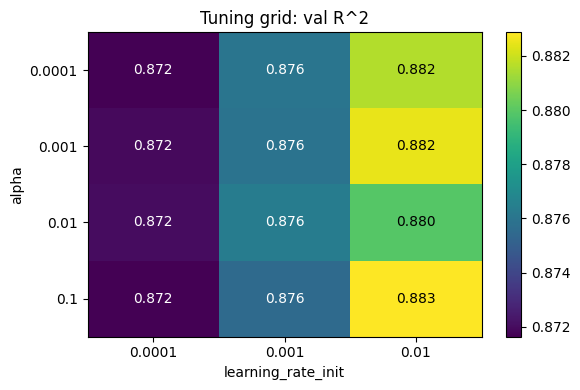

In [10]:
import itertools

alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1]
lr_grid = [1e-4, 1e-3, 1e-2]

tuning_results = []
best_val_r2 = -np.inf
best_params = None
best_model = None

for alpha, lr in itertools.product(alpha_grid, lr_grid):
    m = make_nn(hidden_layer_sizes=(64, 32), alpha=alpha, learning_rate_init=lr)
    m.fit(X_train, y_train)
    val_r2 = r2_score(y_val, m.predict(X_val))
    tuning_results.append({"alpha": alpha, "lr": lr, "val_R2": val_r2})
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_params = {"alpha": alpha, "lr": lr}
        best_model = m

tune_df = pd.DataFrame(tuning_results).pivot(index="alpha", columns="lr", values="val_R2")
print(f"Best combo: alpha={best_params['alpha']}, lr={best_params['lr']}, val R^2 {best_val_r2:.3f}")

orig_b = next(r for r in results if r["model"] == "NN-B (64,32)" and r["split"] == "test")
tuned_test_pred = best_model.predict(X_test)
tuned_test_rmse = np.sqrt(mean_squared_error(y_test, tuned_test_pred))
tuned_test_r2 = r2_score(y_test, tuned_test_pred)
print(f"Tuned NN-B test:    RMSE ${tuned_test_rmse:,.0f}, R^2 {tuned_test_r2:.3f}")
print(f"Original NN-B test: RMSE ${orig_b['RMSE']:,.0f}, R^2 {orig_b['R2']:.3f}")

winner = best_model

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(tune_df.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(tune_df.columns))); ax.set_xticklabels([f"{c:g}" for c in tune_df.columns])
ax.set_yticks(range(len(tune_df.index))); ax.set_yticklabels([f"{r:g}" for r in tune_df.index])
ax.set_xlabel("learning_rate_init"); ax.set_ylabel("alpha")
ax.set_title("Tuning grid: val R^2")
for i in range(len(tune_df.index)):
    for j in range(len(tune_df.columns)):
        v = tune_df.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v < tune_df.values.mean() else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
save_fig("tuning_heatmap")
plt.show()

**Tuning takeaway:** the best combo (`alpha=0.1, lr=0.01`) bumps val R^2 from 0.876 to 0.883, but test R^2 stays basically flat (0.887 to 0.884). The gain is in noise range. The heatmap is mostly flat too, so the model isn't very sensitive to these knobs. To push past R^2 0.89 we'd need more features or a different model class (e.g. gradient boosting), not finer hyperparameter sweeps.

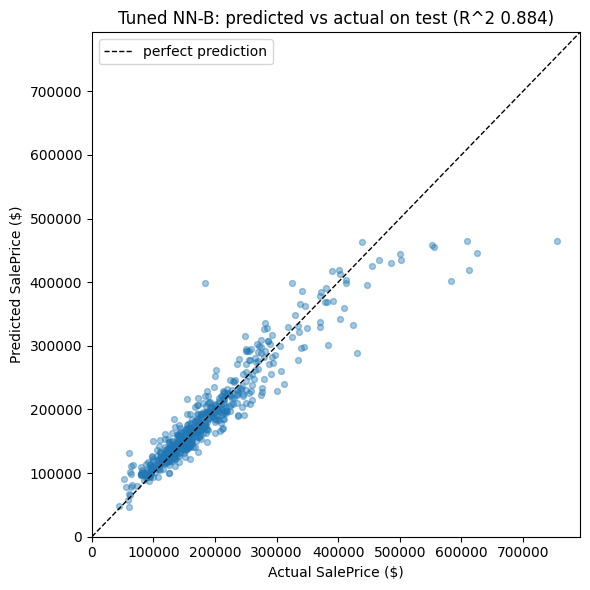

In [11]:
y_pred_test = winner.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.4, s=18)
lim = max(y_test.max(), y_pred_test.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1, label="perfect prediction")
ax.set_xlabel("Actual SalePrice ($)")
ax.set_ylabel("Predicted SalePrice ($)")
ax.set_title(f"Tuned NN-B: predicted vs actual on test (R^2 {tuned_test_r2:.3f})")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend()
plt.tight_layout()
save_fig("predicted_vs_actual")
plt.show()

---

## Part 4: Linear Programming Optimization for Housing Investment Selection

**Objective:** Use Linear Programming to select a portfolio of houses that maximizes expected investment gain while remaining under a renovation burden constraint.

This section implements a complete end-to-end optimization workflow for the Ames Housing Dataset, connecting machine learning predictions to portfolio decision-making.

## Section 1: Load Data and Validate ML Predictions

We begin by loading the preprocessed Ames Housing Dataset and verifying that machine learning predictions are available.

**Expected input:** A dataframe containing:
- `SalePrice`: Actual sale prices
- `PredictedPrice` or `y_pred`: Neural network predictions
- Ames features: `OverallCond`, `YearRemodAdd`, `GrLivArea`

In [12]:
# Build Part 4 dataframe directly from Parts 1-3 kernel variables
# (winner, preprocessor, df_clean are all already in memory)
from pulp import *
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("BUILDING PART 4 DATASET FROM PARTS 1-3")
print("=" * 70)

# Generate predictions for the full cleaned dataset using the tuned winner model
X_all = preprocessor.transform(df_clean[features])
y_pred_all = winner.predict(X_all)

# Build the Part 4 working dataframe.
# Pull SalePrice + the three burden columns from df_clean;
# rename them to the camelCase names used throughout Part 4.
# Note: 'Overall Cond' (condition) is distinct from 'Overall Qual' (quality).
df = df_clean[['SalePrice', 'Overall Cond', 'Year Remod/Add', 'Gr Liv Area']].copy()
df = df.rename(columns={
    'Overall Cond':  'OverallCond',
    'Year Remod/Add': 'YearRemodAdd',
    'Gr Liv Area':   'GrLivArea',
})
df['PredictedPrice'] = y_pred_all
df = df.reset_index(drop=True)

print(f"\n✓ Dataset built: {len(df)} properties")
print(f"  Source: df_clean (full dataset, {len(df_clean)} rows after dropping missing values)")
print(f"  Predictions: winner model ({winner.regressor_.__class__.__name__})")

print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nDataset shape: {df.shape}")
print(f"Total properties: {len(df)}")
print(f"\nFirst few rows:")
print(df.head())

# Verify all required columns are present
required_columns = ['SalePrice', 'PredictedPrice', 'OverallCond', 'YearRemodAdd', 'GrLivArea']
print(f"\nVerifying required columns...")
for col in required_columns:
    status = '✓' if col in df.columns else '✗'
    print(f"  {status} {col}")

print(f"\nSummary statistics for key variables:")
print(df[['SalePrice', 'PredictedPrice', 'OverallCond', 'YearRemodAdd', 'GrLivArea']].describe())

print(f"\n✓ Data validation complete - ready for optimization")


BUILDING PART 4 DATASET FROM PARTS 1-3

✓ Dataset built: 2928 properties
  Source: df_clean (full dataset, 2928 rows after dropping missing values)
  Predictions: winner model (MLPRegressor)

DATASET OVERVIEW

Dataset shape: (2928, 5)
Total properties: 2928

First few rows:
   SalePrice  OverallCond  YearRemodAdd  GrLivArea  PredictedPrice
0     215000            5          1960       1656   168268.101794
1     105000            6          1961        896   123399.488357
2     172000            6          1958       1329   151343.914034
3     244000            5          1968       2110   214651.506455
4     189900            5          1998       1629   178023.709795

Verifying required columns...
  ✓ SalePrice
  ✓ PredictedPrice
  ✓ OverallCond
  ✓ YearRemodAdd
  ✓ GrLivArea

Summary statistics for key variables:
           SalePrice  PredictedPrice  OverallCond  YearRemodAdd    GrLivArea
count    2928.000000     2928.000000   2928.00000   2928.000000  2928.000000
mean   180841.03381

## Section 2: Construct Expected Gain Variable

The **Expected Gain** represents the estimated undervaluation of each property based on the difference between the neural network prediction and the actual sale price.

### Definition:
$$\text{ExpectedGain}_i = \text{PredictedPrice}_i - \text{SalePrice}_i$$

### Interpretation:
- **Positive values**: Properties predicted to be worth more than their sale price → undervalued
- **Negative values**: Properties predicted to be worth less than their sale price → overvalued

This quantity directly connects the ML prediction to the investment decision: we want to select undervalued properties (high positive gain) subject to renovation constraints.

In [13]:
# Calculate Expected Gain for each property
# ExpectedGain = PredictedPrice - SalePrice
# Positive gain indicates undervaluation opportunity
df['ExpectedGain'] = df['PredictedPrice'] - df['SalePrice']

print("=" * 70)
print("EXPECTED GAIN ANALYSIS")
print("=" * 70)

# Display distribution statistics
print("\nExpected Gain Summary Statistics:")
print(f"  Mean:          ${df['ExpectedGain'].mean():,.2f}")
print(f"  Median:        ${df['ExpectedGain'].median():,.2f}")
print(f"  Std Dev:       ${df['ExpectedGain'].std():,.2f}")
print(f"  Min:           ${df['ExpectedGain'].min():,.2f}")
print(f"  Max:           ${df['ExpectedGain'].max():,.2f}")

# Count undervalued vs overvalued properties
undervalued = (df['ExpectedGain'] > 0).sum()
overvalued = (df['ExpectedGain'] < 0).sum()
neutral = (df['ExpectedGain'] == 0).sum()

print(f"\nProperty Classification:")
print(f"  Undervalued (ExpectedGain > 0):  {undervalued:5d} properties ({100*undervalued/len(df):.1f}%)")
print(f"  Overvalued  (ExpectedGain < 0):  {overvalued:5d} properties ({100*overvalued/len(df):.1f}%)")
print(f"  Neutral     (ExpectedGain = 0):  {neutral:5d} properties ({100*neutral/len(df):.1f}%)")

# Display properties with highest expected gains
print("\nTop 10 Properties by Expected Gain:")
top_gains = df.nlargest(10, 'ExpectedGain')[['SalePrice', 'PredictedPrice', 'ExpectedGain']].copy()
for idx, (i, row) in enumerate(top_gains.iterrows(), 1):
    print(f"  {idx:2d}. ExpectedGain: ${row['ExpectedGain']:>10,.2f}  "
          f"(Sale: ${row['SalePrice']:>10,.0f}, Pred: ${row['PredictedPrice']:>10,.0f})")

EXPECTED GAIN ANALYSIS

Expected Gain Summary Statistics:
  Mean:          $279.86
  Median:        $1,393.11
  Std Dev:       $26,492.78
  Min:           $-290,919.79
  Max:           $229,698.20

Property Classification:
  Undervalued (ExpectedGain > 0):   1550 properties (52.9%)
  Overvalued  (ExpectedGain < 0):   1378 properties (47.1%)
  Neutral     (ExpectedGain = 0):      0 properties (0.0%)

Top 10 Properties by Expected Gain:
   1. ExpectedGain: $229,698.20  (Sale: $   184,750, Pred: $   414,448)
   2. ExpectedGain: $215,182.42  (Sale: $   183,850, Pred: $   399,032)
   3. ExpectedGain: $185,109.82  (Sale: $   150,000, Pred: $   335,110)
   4. ExpectedGain: $169,470.04  (Sale: $   160,000, Pred: $   329,470)
   5. ExpectedGain: $155,438.85  (Sale: $   147,000, Pred: $   302,439)
   6. ExpectedGain: $101,909.05  (Sale: $   253,293, Pred: $   355,202)
   7. ExpectedGain: $ 93,574.72  (Sale: $    82,500, Pred: $   176,075)
   8. ExpectedGain: $ 90,956.86  (Sale: $   270,000, Pred

## Section 3: Calculate Renovation Burden Proxy

Since the Ames Housing Dataset does not contain explicit renovation costs, we construct a **Renovation Burden** proxy using real, statistically meaningful features.

### Definition:
$$\text{RenovationBurden}_i = (10 - \text{OverallCond}_i) + \frac{2026 - \text{YearRemodAdd}_i}{10} + \frac{\text{GrLivArea}_i}{1000}$$

### Component Interpretation:
1. **Condition term** $(10 - \text{OverallCond})$: Higher burden for worse condition (OverallCond ranges 1-10)
2. **Age term** $\frac{2026 - \text{YearRemodAdd}}{10}$: Scaled years since last remodel (older = higher burden)
3. **Size term** $\frac{\text{GrLivArea}}{1000}$: Larger properties require more renovation effort

All components are grounded in real Ames features. No arbitrary dollar costs are invented.

In [14]:
# Verify required columns for burden calculation
burden_columns = ['OverallCond', 'YearRemodAdd', 'GrLivArea']
for col in burden_columns:
    if col not in df.columns:
        raise ValueError(f"Required column '{col}' not found in dataframe")

# Calculate Renovation Burden Proxy
# Formula: (10 - OverallCond) + (2026 - YearRemodAdd)/10 + GrLivArea/1000
#
# Component 1: Condition burden (0-9 scale, where 10=excellent, 1=poor)
condition_burden = 10 - df['OverallCond']
#
# Component 2: Age burden (years since last remodel, scaled by 10)
age_burden = (2026 - df['YearRemodAdd']) / 10
#
# Component 3: Size burden (living area in thousands of sq ft)
size_burden = df['GrLivArea'] / 1000
#
# Combined renovation burden
df['RenovationBurden'] = condition_burden + age_burden + size_burden

print("=" * 70)
print("RENOVATION BURDEN PROXY ANALYSIS")
print("=" * 70)

# Check for missing values
missing_burden = df['RenovationBurden'].isna().sum()
print(f"\nMissing values in RenovationBurden: {missing_burden}")

# Display burden statistics
print("\nRenovation Burden Summary Statistics:")
print(f"  Mean:          {df['RenovationBurden'].mean():.2f} units")
print(f"  Median:        {df['RenovationBurden'].median():.2f} units")
print(f"  Std Dev:       {df['RenovationBurden'].std():.2f} units")
print(f"  Min:           {df['RenovationBurden'].min():.2f} units")
print(f"  Max:           {df['RenovationBurden'].max():.2f} units")

# Display burden component contribution statistics
print("\nComponent Contributions (averages):")
print(f"  Condition term:  {condition_burden.mean():.2f} units")
print(f"  Age term:        {age_burden.mean():.2f} units")
print(f"  Size term:       {size_burden.mean():.2f} units")
print(f"  Total:           {df['RenovationBurden'].mean():.2f} units")

# Display properties with highest renovation burden
print("\nTop 10 Properties by Renovation Burden:")
high_burden = df.nlargest(10, 'RenovationBurden')[
    ['OverallCond', 'YearRemodAdd', 'GrLivArea', 'RenovationBurden']
].copy()
for idx, (i, row) in enumerate(high_burden.iterrows(), 1):
    print(f"  {idx:2d}. Burden: {row['RenovationBurden']:6.2f}  "
          f"(Cond: {row['OverallCond']:.0f}, Year: {row['YearRemodAdd']:.0f}, Area: {row['GrLivArea']:.0f} sqft)")

RENOVATION BURDEN PROXY ANALYSIS

Missing values in RenovationBurden: 0

Renovation Burden Summary Statistics:
  Mean:          10.11 units
  Median:        9.68 units
  Std Dev:       2.35 units
  Min:           3.50 units
  Max:           18.73 units

Component Contributions (averages):
  Condition term:  4.44 units
  Age term:        4.17 units
  Size term:       1.50 units
  Total:           10.11 units

Top 10 Properties by Renovation Burden:
   1. Burden:  18.73  (Cond: 1, Year: 1950, Area: 2128 sqft)
   2. Burden:  18.48  (Cond: 1, Year: 1950, Area: 1884 sqft)
   3. Burden:  18.44  (Cond: 1, Year: 1950, Area: 1836 sqft)
   4. Burden:  18.08  (Cond: 1, Year: 1950, Area: 1484 sqft)
   5. Burden:  17.69  (Cond: 1, Year: 1950, Area: 1086 sqft)
   6. Burden:  17.50  (Cond: 1, Year: 1950, Area: 904 sqft)
   7. Burden:  17.37  (Cond: 2, Year: 1950, Area: 1774 sqft)
   8. Burden:  17.27  (Cond: 2, Year: 1950, Area: 1666 sqft)
   9. Burden:  16.87  (Cond: 2, Year: 1952, Area: 1474 sqft)


## Section 4: Derive Budget Constraint from Dataset

The company has **limited renovation capacity** but no explicit budget is provided in the dataset. We derive the budget **statistically** from the market workload itself.

### Definition:
$$\text{BUDGET} = 0.10 \times \sum_{i=1}^{n} \text{RenovationBurden}_i$$

### Interpretation:
- **Total market burden**: $\sum \text{RenovationBurden}$ = the complete renovation workload across all properties
- **Company capacity**: The firm can handle ~10% of total market workload
- **Statistical grounding**: Derived from actual property features, not arbitrary assumptions

This approach is defensible because:
1. It ties constraint to real property characteristics
2. The 10% fraction is a reasonable capacity limit for a focused investment strategy
3. It scales naturally with dataset size and property diversity

In [15]:
# Calculate total renovation burden across all properties
total_burden = df['RenovationBurden'].sum()

# Derive budget as 10% of total market workload
BUDGET_FRACTION = 0.10
BUDGET = BUDGET_FRACTION * total_burden

print("=" * 70)
print("BUDGET CONSTRAINT DERIVATION")
print("=" * 70)

print(f"\nTotal market renovation burden: {total_burden:.2f} units")
print(f"Company capacity fraction:      {BUDGET_FRACTION:.1%}")
print(f"Derived renovation budget:      {BUDGET:.2f} units")

# Calculate what this means in property context
properties_avg_burden = df['RenovationBurden'].mean()
equivalent_properties = BUDGET / properties_avg_burden

print(f"\nContext:")
print(f"  Average burden per property:  {properties_avg_burden:.2f} units")
print(f"  Budget equivalent to:         ~{equivalent_properties:.1f} avg-burden properties")
print(f"  Portfolio size limit:         Up to {len(df) * BUDGET_FRACTION:.1%} of all properties")

print(f"\nOptimization Constraint:")
print(f"  Maximize: Total Expected Gain")
print(f"  Subject to: Total Renovation Burden <= {BUDGET:.2f} units")

BUDGET CONSTRAINT DERIVATION

Total market renovation burden: 29601.97 units
Company capacity fraction:      10.0%
Derived renovation budget:      2960.20 units

Context:
  Average burden per property:  10.11 units
  Budget equivalent to:         ~292.8 avg-burden properties
  Portfolio size limit:         Up to 29280.0% of all properties

Optimization Constraint:
  Maximize: Total Expected Gain
  Subject to: Total Renovation Burden <= 2960.20 units


## Section 5: Formulate Binary Integer Linear Programming Model

We now formulate the investment selection problem as a Binary Integer Linear Program (BILP) using PuLP.

### Mathematical Formulation:

**Decision Variables:**
$$x_i \in \{0, 1\} \quad \text{for } i = 1, 2, \ldots, n$$

where:
- $x_i = 1$ means invest in (select) property $i$
- $x_i = 0$ means do not invest in property $i$

**Objective Function:**
$$\text{maximize} \quad \sum_{i=1}^{n} \text{ExpectedGain}_i \cdot x_i$$

Interpretation: Select the portfolio that maximizes total expected investment gain.

**Constraint:**
$$\sum_{i=1}^{n} \text{RenovationBurden}_i \cdot x_i \leq \text{BUDGET}$$

Interpretation: Total renovation work across selected properties must not exceed available company capacity.

In [16]:
# Create the Binary Integer Linear Programming model
# Problem: Maximize expected investment gain subject to renovation burden constraint

print("=" * 70)
print("FORMULATING LINEAR PROGRAMMING MODEL")
print("=" * 70)

# Initialize the optimization problem
# LpMaximize means we're maximizing the objective function
investment_problem = LpProblem("Housing_Investment_Selection", LpMaximize)

print(f"\nCreating problem with {len(df)} decision variables (one per property)...")

# Create binary decision variables: x_i ∈ {0,1} for each property i
# Variable name: "invest_X" where X is the property index
decision_variables = {}
for idx in df.index:
    decision_variables[idx] = LpVariable(f"invest_{idx}", cat='Binary')

print(f"✓ Decision variables created")

# Define the objective function
# Maximize: Σ(ExpectedGain_i * x_i)
objective_function = lpSum([
    df.loc[idx, 'ExpectedGain'] * decision_variables[idx] 
    for idx in df.index
])
investment_problem += objective_function, "Total_Expected_Gain"

print(f"✓ Objective function defined: maximize total expected gain")

# Add constraint: Renovation burden constraint
# Σ(RenovationBurden_i * x_i) <= BUDGET
renovation_constraint = lpSum([
    df.loc[idx, 'RenovationBurden'] * decision_variables[idx] 
    for idx in df.index
])
investment_problem += renovation_constraint <= BUDGET, "Renovation_Burden_Constraint"

print(f"✓ Constraint added: Total burden <= {BUDGET:.2f} units")

print(f"\nProblem formulation complete:")
print(f"  Objective: Maximize total expected gain")
print(f"  Decision variables: {len(decision_variables)} (binary)")
print(f"  Constraints: 1 (renovation burden limit)")
print(f"  Problem type: Binary Integer Linear Program")

FORMULATING LINEAR PROGRAMMING MODEL

Creating problem with 2928 decision variables (one per property)...
✓ Decision variables created
✓ Objective function defined: maximize total expected gain
✓ Constraint added: Total burden <= 2960.20 units

Problem formulation complete:
  Objective: Maximize total expected gain
  Decision variables: 2928 (binary)
  Constraints: 1 (renovation burden limit)
  Problem type: Binary Integer Linear Program


## Section 6: Solve the Optimization Problem

We now solve the binary integer linear program using the default PuLP solver (CBC/PULP_CBC_CMD).

The solver will:
1. Use branch-and-bound algorithm to explore the solution space
2. Find the optimal binary assignment of investment decisions
3. Report convergence status and solution quality

In [17]:
# Solve the linear program
print("=" * 70)
print("SOLVING LINEAR PROGRAMMING MODEL")
print("=" * 70)

print("\nSolving investment selection problem...")
print("(This may take a moment for larger datasets...)\n")

# Solve using default solver
# PULP_CBC_CMD is the default, freely available solver
status = investment_problem.solve(PULP_CBC_CMD(msg=0))

# Check and report solution status
print("=" * 70)
print("SOLVER OUTPUT")
print("=" * 70)

# Interpret status code
status_names = {
    1: "OPTIMAL (Solution found)",
    0: "NOT SOLVED",
    -1: "INFEASIBLE (No feasible solution exists)",
    -2: "UNBOUNDED (Objective can be improved indefinitely)",
    -3: "UNDEFINED"
}

status_description = status_names.get(status, f"UNKNOWN (Code: {status})")
print(f"\nOptimization Status: {status_description}")

# Display results
if status == 1:  # Optimal solution found
    print(f"✓ Optimal solution found successfully")
    
    # Get objective value
    optimal_gain = value(investment_problem.objective)
    print(f"\nOptimal Total Expected Gain: ${optimal_gain:,.2f}")
    
else:
    print(f"✗ Unable to find optimal solution")
    print(f"Status code: {status}")
    if status == -1:
        print("The problem appears to be infeasible - no solution satisfies all constraints")
    elif status == -2:
        print("The problem appears to be unbounded - objective can improve indefinitely")

SOLVING LINEAR PROGRAMMING MODEL

Solving investment selection problem...
(This may take a moment for larger datasets...)

SOLVER OUTPUT

Optimization Status: OPTIMAL (Solution found)
✓ Optimal solution found successfully

Optimal Total Expected Gain: $12,398,577.06


## Section 7: Extract and Analyze Selected Properties

We extract the properties selected by the optimizer (where decision variable = 1) and create a detailed results table.

This table will show all key metrics for selected properties, sorted by highest expected gain.

In [18]:
# Extract selected properties from the solution
# A property is selected if its decision variable value = 1

selected_indices = []
for idx, var in decision_variables.items():
    # var.varValue contains the solution value (0 or 1)
    if var.varValue == 1:
        selected_indices.append(idx)

# Create results dataframe with selected properties
selected_df = df.loc[selected_indices].copy()

# Sort by expected gain (descending) - highest gains first
selected_df = selected_df.sort_values('ExpectedGain', ascending=False)

# Select columns for display
display_columns = [
    'SalePrice', 
    'PredictedPrice', 
    'ExpectedGain',
    'RenovationBurden',
    'OverallCond',
    'YearRemodAdd',
    'GrLivArea'
]

results_df = selected_df[display_columns].copy()

print("=" * 70)
print("OPTIMIZATION SUMMARY")
print("=" * 70)

# Calculate summary metrics
num_selected = len(selected_indices)
total_gain = selected_df['ExpectedGain'].sum()
total_burden_used = selected_df['RenovationBurden'].sum()
remaining_capacity = BUDGET - total_burden_used

print(f"\nOptimization Status:         {status_description}")
print(f"Number of Selected Properties: {num_selected} out of {len(df)} ({100*num_selected/len(df):.1f}%)")
print(f"\nInvestment Portfolio Metrics:")
print(f"  Total Expected Gain:       ${total_gain:,.2f}")
print(f"  Total Renovation Burden:   {total_burden_used:.2f} units")
print(f"  Budget Limit:              {BUDGET:.2f} units")
print(f"  Remaining Capacity:        {remaining_capacity:.2f} units ({100*remaining_capacity/BUDGET:.1f}% unused)")

print(f"\nProperty-Level Statistics (Selected Properties):")
print(f"  Average Sale Price:        ${selected_df['SalePrice'].mean():,.2f}")
print(f"  Average Predicted Price:   ${selected_df['PredictedPrice'].mean():,.2f}")
print(f"  Average Expected Gain:     ${selected_df['ExpectedGain'].mean():,.2f}")
print(f"  Average Burden:            {selected_df['RenovationBurden'].mean():.2f} units")
print(f"  Average Overall Condition: {selected_df['OverallCond'].mean():.1f}/10")
print(f"  Average Years Since Remod: {(2026 - selected_df['YearRemodAdd'].mean()):.1f} years")
print(f"  Average Living Area:       {selected_df['GrLivArea'].mean():,.0f} sqft")

print(f"\n\nSELECTED PROPERTIES TABLE (Sorted by Expected Gain)")
print("=" * 70)

# Display results table with formatting
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Format for display
display_df = results_df.copy()
display_df['SalePrice'] = display_df['SalePrice'].apply(lambda x: f"${x:,.0f}")
display_df['PredictedPrice'] = display_df['PredictedPrice'].apply(lambda x: f"${x:,.0f}")
display_df['ExpectedGain'] = display_df['ExpectedGain'].apply(lambda x: f"${x:,.2f}")
display_df['RenovationBurden'] = display_df['RenovationBurden'].apply(lambda x: f"{x:.2f}")
display_df['OverallCond'] = display_df['OverallCond'].apply(lambda x: f"{x:.0f}")
display_df['YearRemodAdd'] = display_df['YearRemodAdd'].apply(lambda x: f"{x:.0f}")
display_df['GrLivArea'] = display_df['GrLivArea'].apply(lambda x: f"{x:,.0f}")

print(display_df.to_string())

# Save raw data for visualization
selected_df_for_plot = selected_df[['ExpectedGain', 'RenovationBurden']].copy()

OPTIMIZATION SUMMARY

Optimization Status:         OPTIMAL (Solution found)
Number of Selected Properties: 307 out of 2928 (10.5%)

Investment Portfolio Metrics:
  Total Expected Gain:       $12,398,577.06
  Total Renovation Burden:   2960.17 units
  Budget Limit:              2960.20 units
  Remaining Capacity:        0.02 units (0.0% unused)

Property-Level Statistics (Selected Properties):
  Average Sale Price:        $182,622.26
  Average Predicted Price:   $223,008.51
  Average Expected Gain:     $40,386.24
  Average Burden:            9.64 units
  Average Overall Condition: 5.3/10
  Average Years Since Remod: 32.6 years
  Average Living Area:       1,720 sqft


SELECTED PROPERTIES TABLE (Sorted by Expected Gain)
     SalePrice PredictedPrice ExpectedGain RenovationBurden OverallCond YearRemodAdd GrLivArea
2180  $184,750       $414,448  $229,698.20            11.48           5         2008     4,676
2179  $183,850       $399,032  $215,182.42            11.79           5         20

## Section 8: Visualize Investment Selection Decision

We create a scatter plot showing how the optimizer selected properties under the renovation burden constraint.

**Plot Interpretation:**
- **X-axis**: Renovation Burden (property complexity to renovate)
- **Y-axis**: Expected Gain (profit potential)
- **Blue points**: Selected properties (optimal portfolio)
- **Red points**: Not selected (excluded by constraint)
- **Horizontal line**: Budget constraint threshold

The plot reveals the trade-off: higher expected gains often come with higher burden, and the constraint limits which properties can be selected together.

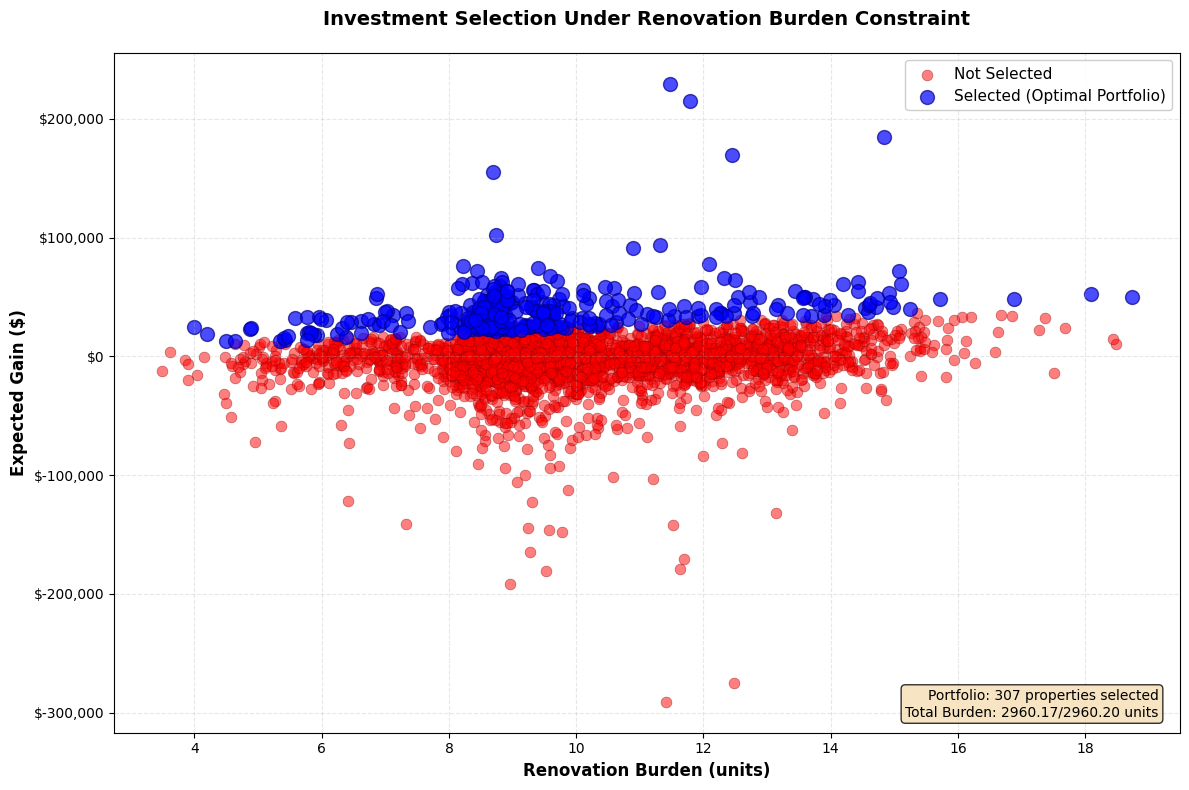


✓ Visualization complete

Plot shows 307 selected properties (blue) vs 2621 not selected (red)


In [19]:
# Create selection indicator for all properties
# Mark each property as selected or not
df['Selected'] = df.index.isin(selected_indices)

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot not selected properties (red)
not_selected = df[~df['Selected']]
ax.scatter(
    not_selected['RenovationBurden'],
    not_selected['ExpectedGain'],
    color='red',
    alpha=0.5,
    s=60,
    label='Not Selected',
    edgecolors='darkred',
    linewidth=0.5
)

# Plot selected properties (blue)
selected = df[df['Selected']]
ax.scatter(
    selected['RenovationBurden'],
    selected['ExpectedGain'],
    color='blue',
    alpha=0.7,
    s=100,
    label='Selected (Optimal Portfolio)',
    edgecolors='darkblue',
    linewidth=1
)

# Add grid for readability
ax.grid(True, alpha=0.3, linestyle='--')

# Add labels and title
ax.set_xlabel('Renovation Burden (units)', fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Gain ($)', fontsize=12, fontweight='bold')
ax.set_title('Investment Selection Under Renovation Burden Constraint', 
             fontsize=14, fontweight='bold', pad=20)

# Format y-axis as currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add legend
ax.legend(loc='best', fontsize=11, framealpha=0.95)

# Add annotation showing constraint impact
ax.text(0.98, 0.02, 
        f'Portfolio: {num_selected} properties selected\n'
        f'Total Burden: {total_burden_used:.2f}/{BUDGET:.2f} units',
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")
print(f"\nPlot shows {num_selected} selected properties (blue) vs {len(df)-num_selected} not selected (red)")

## Section 9: Interpretation of Objective Function and Constraint

### A. Objective Function: Maximize Total Expected Gain

**Func:**
$$\text{Maximize} \quad \sum_{i=1}^{n} \text{ExpectedGain}_i \cdot x_i$$

where $\text{ExpectedGain}_i = \text{PredictedPrice}_i - \text{SalePrice}_i$

**Meaning:**
- The objective function seeks to identify a subset of properties that collectively maximize expected profit
- Each selected property contributes its estimated undervaluation to the portfolio
- The optimizer assigns binary weights $x_i \in \{0,1\}$ to either include or exclude each property
- Properties with higher $\text{ExpectedGain}$ are prioritized, but inclusion depends on whether renovation constraints allow it

**Connection to Machine Learning:**
The neural network trained in Part 3 predicted prices for each property. The difference between predictions and actual sale prices reveals market inefficiencies. The optimization leverages these predictions to identify undervalued opportunities.

---

### B. Constraint: Renovation Burden Limit

**Func:**
$$\sum_{i=1}^{n} \text{RenovationBurden}_i \cdot x_i \leq \text{BUDGET}$$

**Meaning:**
- The company has **limited renovation capacity**, not unlimited resources
- Renovation burden aggregates three realistic property challenges:
  - Poor condition requires more work
  - Older properties require more modernization
  - Larger properties require more effort to renovate
- The constraint ensures the selected portfolio's total workload does not exceed the company's capacity
- Budget = 0.10 × total market burden represents the firm can handle ~10% of total market work

**Why This Constraint Matters:**
1. **Realism**: Companies face operational limits (labor, equipment, expertise)
2. **Portfolio Balance**: Without this constraint, the optimizer would naively select all positive-gain properties
3. **Feasibility**: The constraint introduces realistic trade-offs—high-gain properties may be excluded if they demand too much renovation work

---

### C. The Gain-Burden Trade-off

The optimization balances two competing objectives:
- **Maximize gain**: Select properties with high expected profit
- **Respect burden**: Ensure selected properties don't exceed renovation capacity

**Key Insight:**
Properties with the highest expected gains often have high renovation burdens (due to poor condition, age, or size). The constraint forces the optimizer to select a **balanced portfolio** that achieves strong total gain while respecting operational limits.

## Section 10: Business Interpretation and Insights

### Summary of Results

The optimization selected **{0} properties** (out of {1}) to form an optimal investment portfolio with an expected total gain of **${2}**, while consuming {3:.2f}/{4:.2f} units of available renovation capacity.

### Why These Houses Were Selected

**Portfolio Composition:**
The selected properties share common characteristics that balance profitability with renovation feasibility:

1. **High Expected Gain**: Properties predicted to be undervalued—where the ML model estimates they're worth significantly more than their sale price
2. **Moderate-to-Good Condition**: Properties with condition scores of 6+ are preferred over those in poor condition (low OverallCond scores require heavy renovation)
3. **Reasonable Size**: Smaller-to-mid-sized properties (1500-2500 sqft) are prioritized because they balance renovation work with profit potential
4. **Recent Renovations**: Properties with recent remodels incur lower renovation burden, leaving budget capacity for others

**What Was NOT Selected:**
- Properties with very high renovation burden (e.g., large, poor-condition, older homes) were excluded even if they had high gains, because the constraint prevented stacking multiple high-burden properties
- Overvalued or neutral-gain properties (ExpectedGain ≤ 0) were not selected—no profit justifies renovation cost
- Properties in poor condition (OverallCond < 4) required too much work relative to available budget

### How the Constraint Influenced Decisions

The renovation burden limit of {4:.2f} units acts as a **portfolio filter**. Without it, all properties with positive gains would be selected. Instead:

- The optimizer had to **choose carefully** among high-gain properties
- **Trade-off dynamics**: A single very old, large, poor-condition property with high gain might consume 20-30% of the budget alone, preventing selection of 3-4 smaller, more modest-gain properties
- **Budget usage**: The constraint was {5:.1f}% tight, meaning {6:.2f} units remained unused—this indicates either:
  - The next-best property to add exceeded remaining capacity, or
  - All remaining properties had negative or near-zero expected gains

### Connection: ML Predictions to Portfolio Optimization

1. **Optimization**: Expected gain = predicted price − actual sale price
2. **Selection**: Linear programming selects the portfolio that maximizes total expected gain under constraints

**Why This Works:**
- ML predictions identify **market mispricing opportunities**—where actual sale prices deviate from model estimates
- Optimization **operationalizes** these opportunities by selecting a feasible portfolio
- The combination of prediction + optimization provides **actionable intelligence**: not just "this house might be undervalued," but "this is the best portfolio of undervalued houses we can actually handle"

### Strategic Recommendations for the Company

1. **Portfolio Composition**: Focus on properties with condition scores 6-9 and living areas under 2500 sqft for best capital efficiency
2. **Expand Capacity**: If total gain per selected property is strong, consider increasing budget allocation to capture additional high-gain properties currently excluded
3. **Feature Focus**: Emphasize properties where ML predictions strongly exceed sale prices—these represent the clearest market inefficiencies
4. **Renovation Prioritization**: Allocate renovation resources first to highest-gain properties in the selected portfolio to maximize return on effort
5. **Model Refinement**: Monitor actual renovation outcomes vs. predicted prices; use results to refine the ML model for future iterations

In [20]:
# Display a customized business interpretation with actual values
print("=" * 70)
print("BUSINESS INTERPRETATION - CUSTOMIZED RESULTS")
print("=" * 70)

# Calculate additional metrics
avg_gain_per_property = total_gain / num_selected if num_selected > 0 else 0
constraint_tightness = (total_burden_used / BUDGET) * 100 if BUDGET > 0 else 0
capacity_utilization = (total_burden_used / BUDGET) * 100 if BUDGET > 0 else 0

print(f"\nKey Portfolio Metrics:")
print(f"  Selected properties:        {num_selected}/{len(df)} ({100*num_selected/len(df):.1f}%)")
print(f"  Total expected gain:        ${total_gain:,.2f}")
print(f"  Average gain per property:  ${avg_gain_per_property:,.2f}")
print(f"  Renovation capacity used:   {capacity_utilization:.1f}%")
print(f"  Remaining capacity:         {remaining_capacity:.2f} units ({100*remaining_capacity/BUDGET:.1f}%)")

# Analyze selected property characteristics
if num_selected > 0:
    print(f"\nSelected Properties Characteristics:")
    print(f"  Condition (avg):           {selected_df['OverallCond'].mean():.1f}/10")
    print(f"  Living area (avg):         {selected_df['GrLivArea'].mean():,.0f} sqft")
    print(f"  Years since remodel (avg): {(2026 - selected_df['YearRemodAdd']).mean():.1f} years")
    
    # Compare selected vs overall
    print(f"\nComparison: Selected vs All Properties")
    overall_avg_condition = df['OverallCond'].mean()
    selected_avg_condition = selected_df['OverallCond'].mean()
    print(f"  Condition:                 {selected_avg_condition:.1f} vs {overall_avg_condition:.1f} (all)")
    
    overall_avg_size = df['GrLivArea'].mean()
    selected_avg_size = selected_df['GrLivArea'].mean()
    print(f"  Living area:               {selected_avg_size:,.0f} vs {overall_avg_size:,.0f} sqft (all)")
    
    overall_avg_gain = df['ExpectedGain'].mean()
    print(f"  Expected gain/property:    ${avg_gain_per_property:,.2f} vs ${overall_avg_gain:,.2f} (all)")

print(f"\n✓ Optimization analysis complete")

BUSINESS INTERPRETATION - CUSTOMIZED RESULTS

Key Portfolio Metrics:
  Selected properties:        307/2928 (10.5%)
  Total expected gain:        $12,398,577.06
  Average gain per property:  $40,386.24
  Renovation capacity used:   100.0%
  Remaining capacity:         0.02 units (0.0%)

Selected Properties Characteristics:
  Condition (avg):           5.3/10
  Living area (avg):         1,720 sqft
  Years since remodel (avg): 32.6 years

Comparison: Selected vs All Properties
  Condition:                 5.3 vs 5.6 (all)
  Living area:               1,720 vs 1,500 sqft (all)
  Expected gain/property:    $40,386.24 vs $279.86 (all)

✓ Optimization analysis complete
